# 🏠 HousePrice 実習ノートブック
## 精度向上の工夫を考えよう（スライド p.94〜）

このノートブックは講習会スライドの **p.94 以降**に対応した実習用コードです。

---

### 本ノートブックの構成

各テーマは **3 パートで構成**されています。

| パート | マーク | 役割 |
|:---|:---:|:---|
| **DEMO** | 🔵 | スライドの解説・デモコード（**触らなくてOK**） |
| **QUIZ** | 🟡 | 穴埋め演習（**`___` の部分を埋めてください**） |
| **FREE** | 🟢 | 自由実装（**自分のアイデアを試す場所**） |

---

### セクション一覧

| # | セクション | スライド | テーマ |
|:---|:---|:---:|:---|
| 0 | セットアップ | — | ライブラリ・データ・ベースライン |
| 1 | EDA：基本統計量 | p.100〜101 | 平均・中央値・標準偏差 |
| 2 | EDA：データを可視化する | p.103〜105 | ヒストグラム・散布図 |
| 3 | EDA：欠損値を吟味する | p.106〜108 | 欠損の種類と補完戦略 |
| 4 | 前処理：スケールと対数変換 | p.102〜103 | 標準化・正規化・対数変換 |
| 5 | 特徴量エンジニアリング | p.113〜117 | 組み合わせ・ドメイン知識 |
| 6 | 特徴量選択 | p.118〜123 | 多重共線性・相関フィルタ |
| 7 | まとめパイプライン＋評価 | — | 全工程を一本化して比較 |
| 8 | 提出ファイル作成 | — | Kaggle 提出用 CSV |


---
## 0. セットアップ

> 🔵 **DEMO** ─ このセクションは触らずに上から順番に実行してください。

ライブラリを読み込み、データをロードして、**ベースライン RMSE** を確認します。  
この値が「改善前の基準スコア」になります。


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# グラフを日本語対応させる（Colab 環境）
!pip install japanize-matplotlib -q
import japanize_matplotlib

print('✅ ライブラリ読み込み完了')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 29.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ ライブラリ読み込み完了


In [ ]:
# ── データ読み込み ───────────────────────────────────────────────────────────
train = pd.read_csv('/content/drive/MyDrive/Kaggle/HousePrice/train.csv')
test  = pd.read_csv('/content/drive/MyDrive/Kaggle/HousePrice/test.csv')

print(f'train: {train.shape}  /  test: {test.shape}')
train.head()

train: (1460, 81)  /  test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# ── ベースライン（前回と同じコード）─────────────────────────────────────────
test_ids = test['Id']

y = np.log1p(train['SalePrice'])
X = train.drop(columns=['SalePrice', 'Id'])
X_test = test.drop(columns=['Id']).copy()

all_data = pd.concat([X, X_test], axis=0).reset_index(drop=True)
numeric_cols     = all_data.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = all_data.select_dtypes(include=['object']).columns

for col in numeric_cols:
    all_data[col] = all_data[col].fillna(all_data[col].median())
for col in categorical_cols:
    all_data[col] = all_data[col].fillna('Missing')

all_data = pd.get_dummies(all_data, drop_first=True)

X_processed      = all_data.iloc[:len(X)].copy()
X_test_processed = all_data.iloc[len(X):].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)
valid_pred_baseline = model_baseline.predict(X_valid)

rmse_baseline = np.sqrt(mean_squared_error(y_valid, valid_pred_baseline))
print(f'\n🔵 【ベースライン RMSE】 {rmse_baseline:.5f}  ← この値を超えることを目指そう！')


🔵 【ベースライン RMSE】 0.17367  ← この値を超えることを目指そう！


---
## 1. EDA：基本統計量を確認しよう（スライド p.100〜101）

> **EDA（Exploratory Data Analysis）** ＝ データを可視化・集計して特徴を探る作業

まずは **基本統計量（平均・中央値・最頻値・分散・標準偏差）** を見て、データ全体の概要を把握します。


### 🔵 DEMO ─ 基本統計量を見てみよう


In [ ]:
# describe() で一覧表示
cols_to_check = ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'YearBuilt']
train[cols_to_check].describe().round(1)

,SalePrice,GrLivArea,LotArea,OverallQual,YearBuilt
count,1460.0,1460.0,1460.0,1460.0,1460.0
mean,180921.2,1515.5,10516.8,6.1,1971.3
std,79442.5,525.5,9981.3,1.4,30.2
min,34900.0,334.0,1300.0,1.0,1872.0
25%,129975.0,1129.5,7553.5,5.0,1954.0
50%,163000.0,1464.0,9478.5,6.0,1973.0
75%,214000.0,1776.8,11601.5,7.0,2000.0
max,755000.0,5642.0,215245.0,10.0,2010.0


平均値  (mean)  : $180,921
中央値  (median): $163,000
最頻値  (mode)  : $140,000


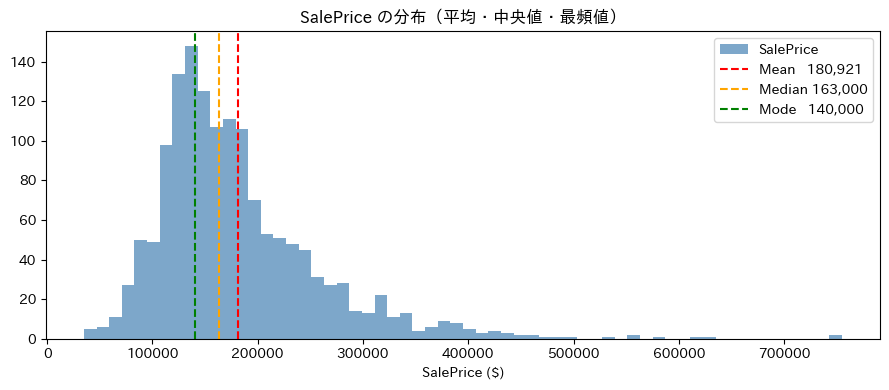

In [ ]:
# 平均・中央値・最頻値を並べて比較し、ヒストグラムに重ねて表示する
target = 'SalePrice'

mean_val   = train[target].mean()
median_val = train[target].median()
mode_val   = train[target].mode()[0]

print(f'平均値  (mean)  : ${mean_val:,.0f}')
print(f'中央値  (median): ${median_val:,.0f}')
print(f'最頻値  (mode)  : ${mode_val:,.0f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train[target], bins=60, color='steelblue', alpha=0.7, label='SalePrice')
ax.axvline(mean_val,   color='red',    linestyle='--', label=f'Mean   {mean_val:,.0f}')
ax.axvline(median_val, color='orange', linestyle='--', label=f'Median {median_val:,.0f}')
ax.axvline(mode_val,   color='green',  linestyle='--', label=f'Mode   {mode_val:,.0f}')
ax.set_xlabel('SalePrice ($)')
ax.set_title('SalePrice の分布（平均・中央値・最頻値）')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 標準偏差ランキング（ばらつきが大きい特徴量を確認）
cols_numeric = train.select_dtypes(include='number').drop(columns=['Id', 'SalePrice'])
std_df = cols_numeric.std().sort_values(ascending=False).head(10).reset_index()
std_df.columns = ['特徴量', '標準偏差']
print('標準偏差が大きい上位 10 特徴量')
print(std_df.to_string(index=False))

標準偏差が大きい上位 10 特徴量
        特徴量        標準偏差
    LotArea 9981.264932
  GrLivArea  525.480383
    MiscVal  496.123024
 BsmtFinSF1  456.098091
  BsmtUnfSF  441.866955
TotalBsmtSF  438.705324
   2ndFlrSF  436.528436
   1stFlrSF  386.587738
 GarageArea  213.804841
 MasVnrArea  181.066207


### 🟡 QUIZ ─ 穴埋め演習：別の特徴量で統計量を確認しよう

`GrLivArea`（地上居住面積）について、平均・中央値・標準偏差を計算し、  
ヒストグラムを描いてみましょう。`___` を埋めてコードを完成させてください。


In [ ]:
# 🟡 QUIZ：GrLivArea の基本統計量を確認する
col = 'GrLivArea'

# ── ❶ 統計量を計算する ──────────────────────────────────────
mean_gl   = train[col].___()           # 平均値
median_gl = train[col].___()           # 中央値
std_gl    = train[col].___()           # 標準偏差

print(f'平均値   : {mean_gl:.1f}')
print(f'中央値   : {median_gl:.1f}')
print(f'標準偏差 : {std_gl:.1f}')

# ── ❷ ヒストグラムを描く ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train[col], bins=___, color='steelblue', alpha=0.7)   # bins の数を決めよう（例: 50）
ax.axvline(___, color='red',    linestyle='--', label='Mean')   # 平均線
ax.axvline(___, color='orange', linestyle='--', label='Median') # 中央線
ax.set_xlabel(col)
ax.set_title(f'{col} の分布')
ax.legend()
plt.tight_layout()
plt.show()

# ── ❸ 考察 ───────────────────────────────────────────────────
# Q: 平均と中央値はどちらが大きいですか？分布はどんな形ですか？
# A: （ここに考えを書いてみよう）


### 🟢 FREE ─ 自由実装：自分が気になる特徴量を調べよう

気になる特徴量を自分で選んで、基本統計量とヒストグラムを確認してみましょう。


In [ ]:
# 🟢 FREE：好きな特徴量を選んで統計量を確認しよう
# ── 使えそうな特徴量の例 ──────────────────────────────────────────────────
# 'LotArea' (土地面積), 'YearBuilt' (建築年), 'OverallQual' (総合品質スコア)
# 'TotalBsmtSF' (地下面積), 'GarageArea' (ガレージ面積) など

# ↓↓↓ ここに自由にコードを書こう ↓↓↓

my_col = 'LotArea'   # ← 変えてみよう

print(train[my_col].describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train[my_col].dropna(), bins=50, color='mediumpurple', alpha=0.7)
ax.set_xlabel(my_col)
ax.set_title(f'{my_col} の分布')
plt.tight_layout()
plt.show()


---
## 2. EDA：データを可視化してみよう（スライド p.103〜105）

グラフを描いて、**目的変数（SalePrice）と各特徴量の関係**を視覚的に探りましょう。


### 🔵 DEMO ─ SalePrice の分布・散布図・箱ひげ図


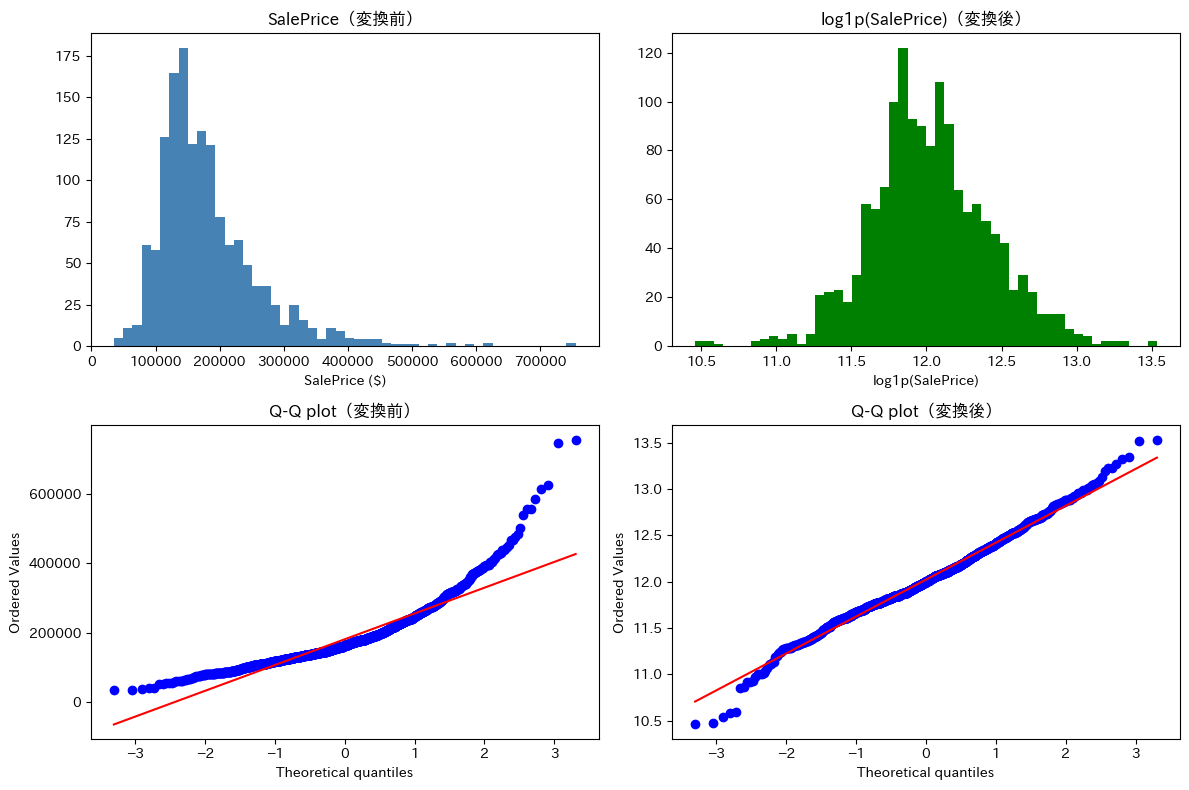

変換前の歪度: 1.883
変換後の歪度: 0.121
💡 歪度が 0 に近いほど正規分布に近い形です


In [ ]:
# SalePrice の分布と対数変換（スライド p.103）
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(train['SalePrice'], bins=50, color='steelblue')
axes[0, 0].set_title('SalePrice（変換前）')
axes[0, 0].set_xlabel('SalePrice ($)')

axes[0, 1].hist(np.log1p(train['SalePrice']), bins=50, color='green')
axes[0, 1].set_title('log1p(SalePrice)（変換後）')
axes[0, 1].set_xlabel('log1p(SalePrice)')

stats.probplot(train['SalePrice'], plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot（変換前）')

stats.probplot(np.log1p(train['SalePrice']), plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot（変換後）')

plt.tight_layout()
plt.show()

print(f'変換前の歪度: {train["SalePrice"].skew():.3f}')
print(f'変換後の歪度: {np.log1p(train["SalePrice"]).skew():.3f}')
print('💡 歪度が 0 に近いほど正規分布に近い形です')

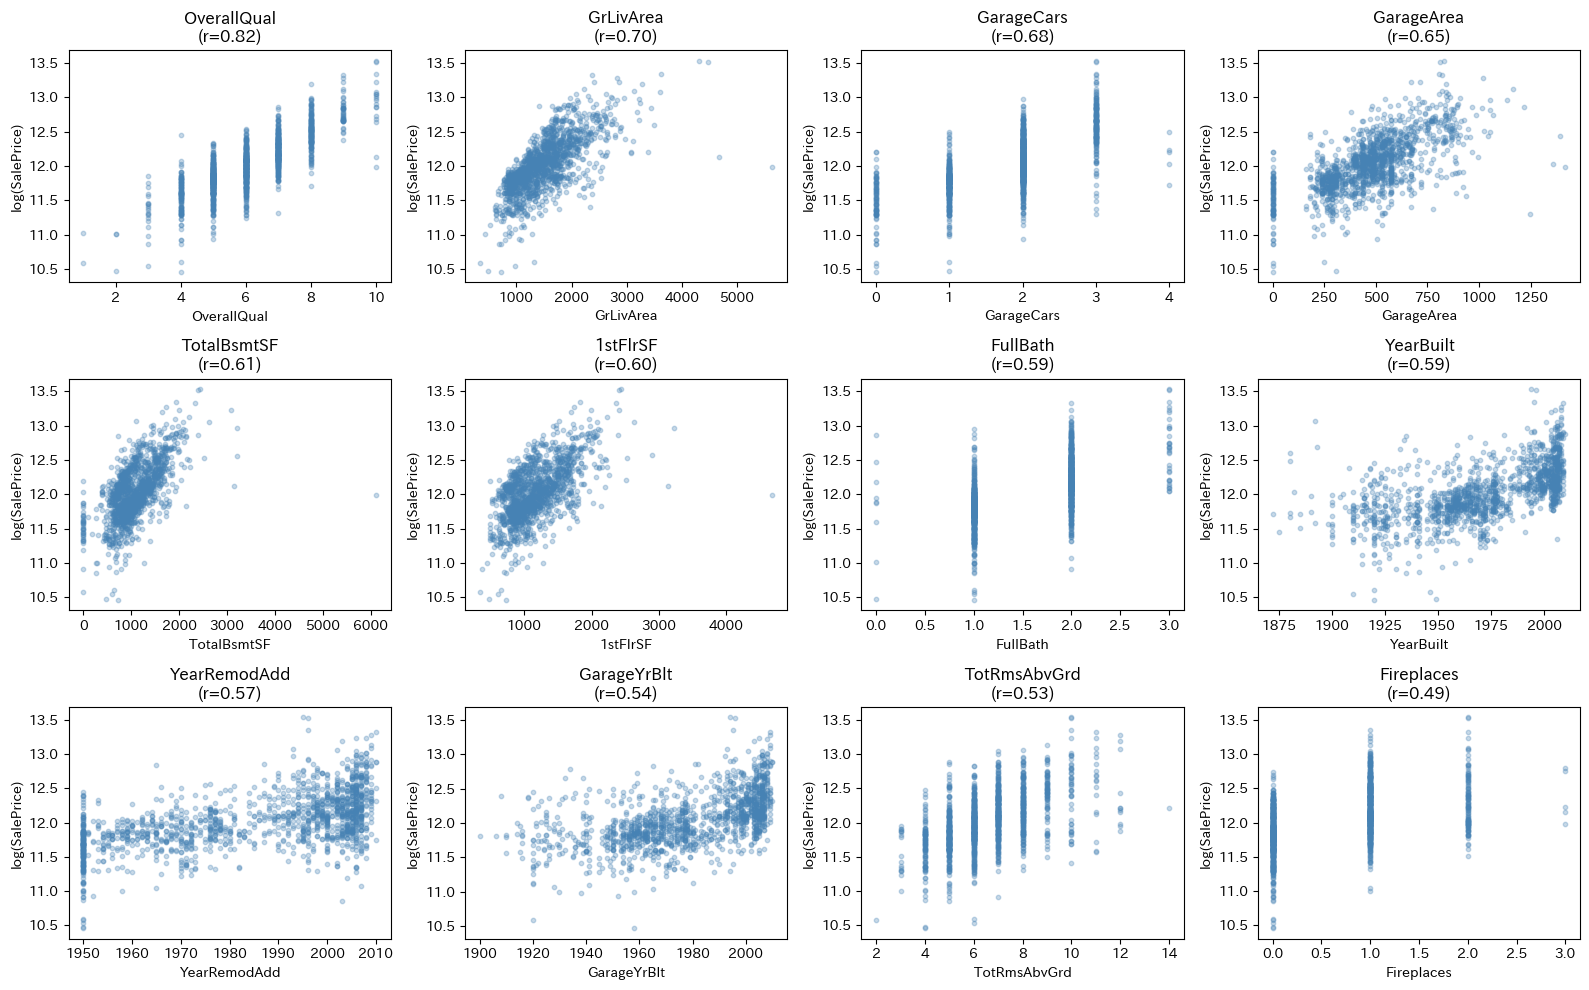

In [ ]:
# SalePrice との相関が高い上位12特徴量を散布図で確認（スライド p.104〜105）
y_log = np.log1p(train['SalePrice'])
X_num = train.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice', 'Id'])

corr_with_y = X_num.corrwith(y_log).abs().sort_values(ascending=False)
top12 = corr_with_y.head(12).index

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top12):
    axes[i].scatter(train[col], y_log, alpha=0.3, s=10, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(SalePrice)')
    axes[i].set_title(f'{col}\n(r={corr_with_y[col]:.2f})')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2311/3174771162.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=sorted(train['OverallQual'].unique()))


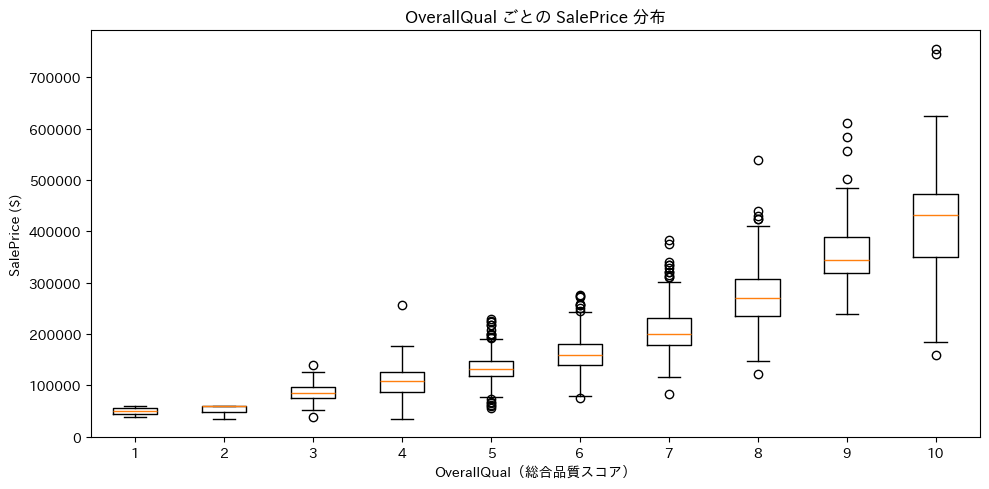

In [ ]:
# カテゴリ変数との関係（OverallQual × SalePrice の箱ひげ図）
fig, ax = plt.subplots(figsize=(10, 5))
groups = [train[train['OverallQual'] == q]['SalePrice']
          for q in sorted(train['OverallQual'].unique())]
ax.boxplot(groups, labels=sorted(train['OverallQual'].unique()))
ax.set_xlabel('OverallQual（総合品質スコア）')
ax.set_ylabel('SalePrice ($)')
ax.set_title('OverallQual ごとの SalePrice 分布')
plt.tight_layout()
plt.show()
#  品質スコアが上がると価格はどう変わりますか？ばらつきは？

### 🟡 QUIZ ─ 穴埋め演習：指定特徴量の散布図を描こう

`YearBuilt`（建築年）と `log1p(SalePrice)` の散布図を描き、  
相関係数 r を計算して、タイトルに表示してみましょう。


In [ ]:
# 🟡 QUIZ：YearBuilt vs log1p(SalePrice) の散布図
col   = 'YearBuilt'
y_log = np.log1p(train['SalePrice'])

# ── ❶ 相関係数を計算する ─────────────────────────────────────
r = train[col].corr(___)   # 相関係数を計算するには何を引数にすればよい？

# ── ❷ 散布図を描く ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train[col], ___, alpha=0.4, s=15, color='steelblue')  # y 軸は何？
ax.set_xlabel(col)
ax.set_ylabel('log1p(SalePrice)')
ax.set_title(f'{col} vs log1p(SalePrice)  (r = {r:.3f})')
plt.tight_layout()
plt.show()

# ── ❸ 考察 ───────────────────────────────────────────────────
# Q: 建築年と価格の間にはどんな傾向がありますか？外れ値はありますか？
# A: （ここに考えを書いてみよう）


TypeError: unsupported type: <class 'str'>

### 🟢 FREE ─ 自由実装：好きな特徴量で散布図・箱ひげ図を描こう


In [ ]:
# 🟢 FREE：自由に可視化してみよう
# ── 試してみると面白い特徴量 ───────────────────────────────────────────────
# 散布図向き : 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea'
# 箱ひげ図向き: 'Neighborhood', 'BldgType', 'KitchenQual'（カテゴリ変数）

# ↓↓↓ ここに自由にコードを書こう ↓↓↓

my_col = 'GrLivArea'   # ← 変えてみよう
y_log  = np.log1p(train['SalePrice'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train[my_col], y_log, alpha=0.4, s=15, color='darkorange')
ax.set_xlabel(my_col)
ax.set_ylabel('log1p(SalePrice)')
r_my = train[my_col].corr(y_log)
ax.set_title(f'{my_col} vs log1p(SalePrice)  (r = {r_my:.3f})')
plt.tight_layout()
plt.show()


---
## 3. EDA：欠損値を吟味しよう（スライド p.106〜108）

欠損値には大きく **2 種類**あります。

| 種類 | 意味 | 対処法の例 |
|:---|:---|:---|
| **データが本当に存在しない** | 計測漏れ・入力ミス | 中央値・平均値・最頻値で補完 |
| **「該当設備なし」を示す NA** | PoolQC=NA → プールなし | 新しいカテゴリ「None」として扱う |


### 🔵 DEMO ─ 欠損の可視化と「NA = 設備なし」の確認


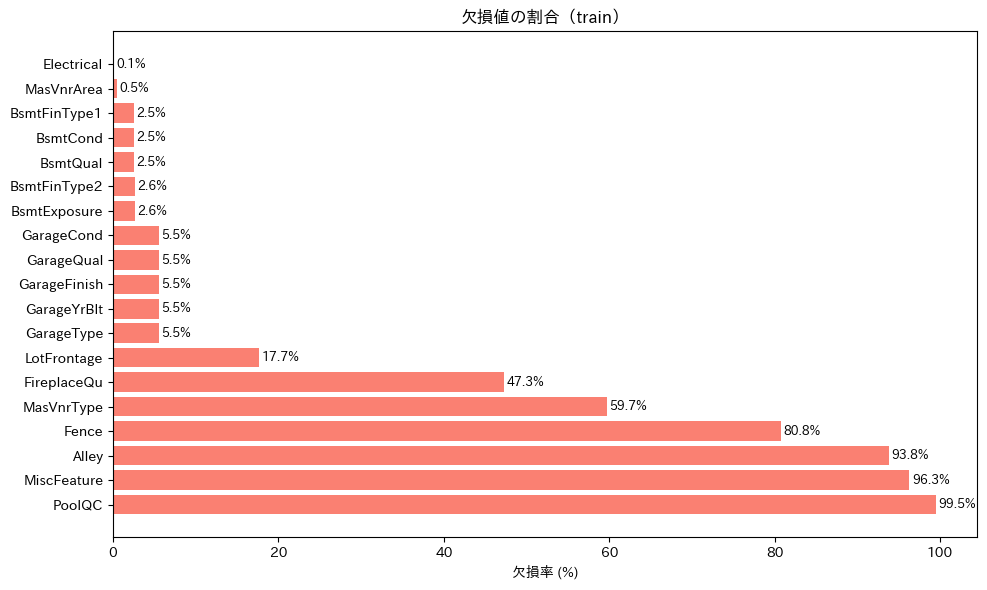

In [ ]:
# 欠損割合を棒グラフで可視化する
def plot_missing(df, title='train'):
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    missing_pct = (missing / len(df) * 100).round(1)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(missing.index, missing_pct.values, color='salmon')
    ax.set_xlabel('欠損率 (%)')
    ax.set_title(f'欠損値の割合（{title}）')
    for bar, val in zip(bars, missing_pct.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_missing(train, 'train')

In [ ]:
# data_description.txt より：NA が「設備なし」を意味する列
na_means_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]

print('=== NA が「設備なし」を意味する列 ===')
for col in na_means_none:
    if col in train.columns:
        n_miss = train[col].isnull().sum()
        pct    = n_miss / len(train) * 100
        print(f'  {col:<20}: 欠損数={n_miss:4d} ({pct:.1f}%)')

=== NA が「設備なし」を意味する列 ===
  PoolQC              : 欠損数=1453 (99.5%)
  MiscFeature         : 欠損数=1406 (96.3%)
  Alley               : 欠損数=1369 (93.8%)
  Fence               : 欠損数=1179 (80.8%)
  FireplaceQu         : 欠損数= 690 (47.3%)
  GarageType          : 欠損数=  81 (5.5%)
  GarageFinish        : 欠損数=  81 (5.5%)
  GarageQual          : 欠損数=  81 (5.5%)
  GarageCond          : 欠損数=  81 (5.5%)
  BsmtQual            : 欠損数=  37 (2.5%)
  BsmtCond            : 欠損数=  37 (2.5%)
  BsmtExposure        : 欠損数=  38 (2.6%)
  BsmtFinType1        : 欠損数=  37 (2.5%)
  BsmtFinType2        : 欠損数=  38 (2.6%)
  MasVnrType          : 欠損数= 872 (59.7%)


### 🟡 QUIZ ─ 穴埋め演習：補完方法を比較しよう

`LotFrontage`（前面道路幅）は「真の欠損」です。  
平均値・中央値・最頻値で補完したときの **分散** を比べて、最もデータの性質を保つ方法はどれか確認しましょう。


In [ ]:
# 🟡 QUIZ：LotFrontage の欠損補完方法を比較する
col      = 'LotFrontage'
original = train[col].copy()

# ── ❶ 3種類の補完を行う ──────────────────────────────────────
fill_mean   = original.fillna(___)              # 平均値で補完
fill_median = original.fillna(___)              # 中央値で補完
fill_mode   = original.fillna(___)              # 最頻値で補完

# ── ❷ 分散を比較して結果を表示する ─────────────────────────────
print(f'{col} の分析')
print(f'  欠損数  : {original.isnull().sum()}')
print(f'  平均値  : {original.mean():.1f}  →  補完後の分散: {fill_mean.var():.1f}')
print(f'  中央値  : {original.median():.1f}  →  補完後の分散: {fill_median.var():.1f}')
print(f'  最頻値  : {original.mode()[0]:.1f}  →  補完後の分散: {fill_mode.var():.1f}')

# ── ❸ ヒストグラムで補完前後を比較する ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(original.dropna(), bins=30, color='salmon',    label='元データ（欠損除外）')
axes[0].set_title('補完前（欠損除く）')
axes[1].hist(___, bins=30, color='steelblue', label='中央値補完')  # 中央値補完の結果を可視化
axes[1].set_title('中央値補完後')
for ax in axes:
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

# ── ❹ 考察 ───────────────────────────────────────────────────
# Q: どの補完方法が分散を最も保てていますか？なぜそう思いますか？
# A: （ここに考えを書いてみよう）


### 🟢 FREE ─ 自由実装：別の列の欠損を調べてみよう


In [ ]:
# 🟢 FREE：気になる欠損列を選んで補完を試してみよう
# ── 欠損が多い列の例 ────────────────────────────────────────────────────
# 数値: 'GarageYrBlt', 'MasVnrArea'  → 中央値補完が基本
# 文字: 'FireplaceQu', 'GarageFinish' → NA = 「設備なし」なので 'None' 補完

# ↓↓↓ ここに自由にコードを書こう ↓↓↓

my_col = 'GarageYrBlt'  # ← 変えてみよう
print(f'{my_col} の欠損数: {train[my_col].isnull().sum()}')
print(train[my_col].describe())

# 補完後の確認
filled = train[my_col].fillna(train[my_col].median())
print(f'補完後の欠損数: {filled.isnull().sum()}')

---
## 4. 前処理：スケールと対数変換（スライド p.102〜103）

特徴量の単位・スケールがバラバラだと、線形モデルでは重みが正しく推定できません。

| 手法 | 概要 | 使いどころ |
|:---|:---|:---|
| **標準化** | 平均0・分散1に変換 | 正規分布に近い数値変数 |
| **正規化** | 0〜1 の範囲に変換 | 外れ値が少ないとき |
| **対数変換** | log(x+1) で歪みを補正 | 右裾が重い分布（価格・面積など） |


### 🔵 DEMO ─ 歪度の高い特徴量を探して対数変換・標準化の効果を確認する


In [ ]:
# 歪度が高い特徴量を特定する
X_num    = train.drop(columns=['SalePrice', 'Id']).select_dtypes(include=['int64', 'float64'])
skewness = X_num.skew().sort_values(ascending=False)
high_skew = skewness[skewness.abs() > 0.75]

print(f'歪度 |skew| > 0.75 の特徴量: {len(high_skew)} 個')
print(high_skew.head(10))

歪度 |skew| > 0.75 の特徴量: 21 個
MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
dtype: float64


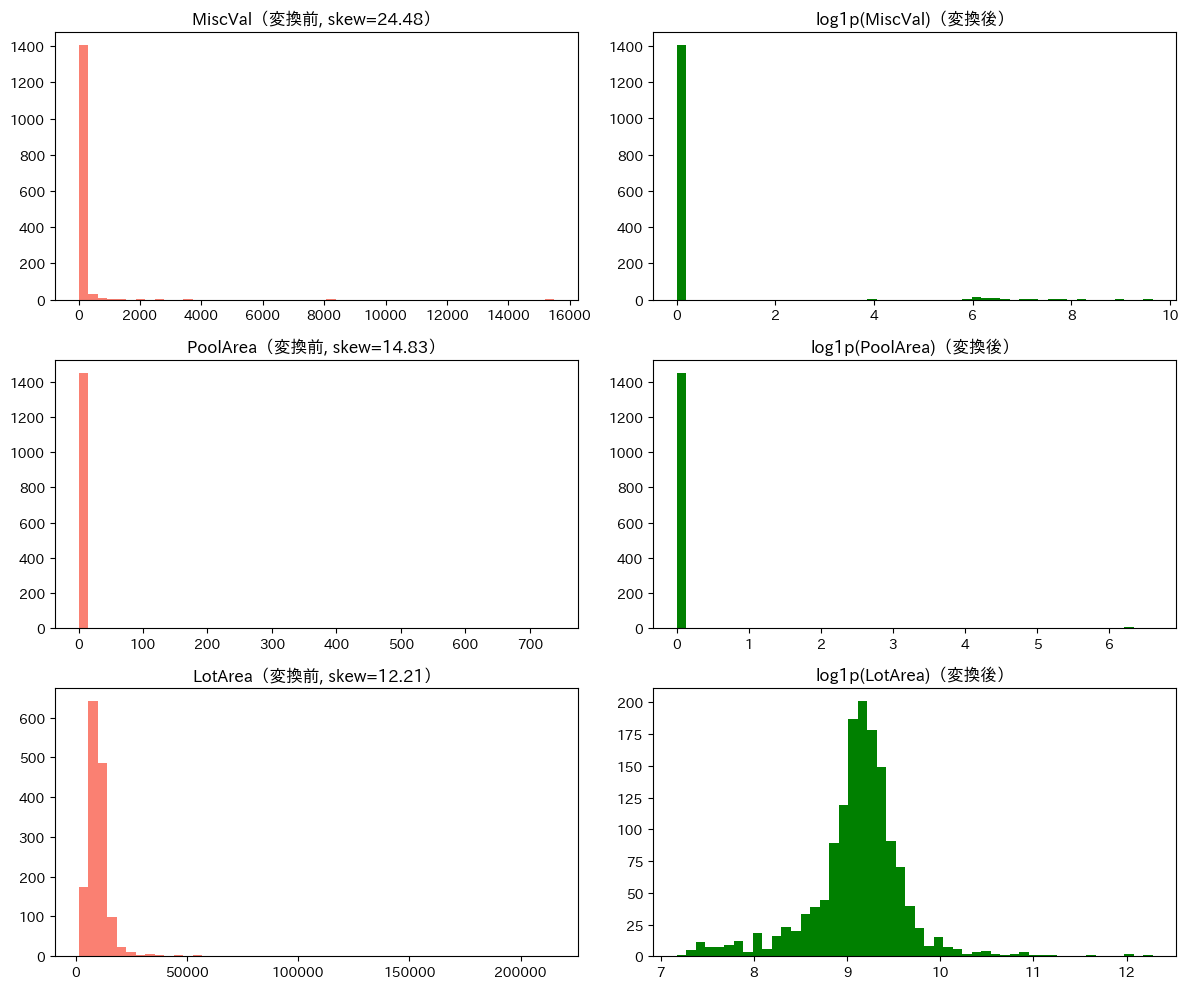

In [ ]:
# 歪度上位 3 特徴量について変換前後を比較
top3_skew = high_skew.head(3).index

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for i, col in enumerate(top3_skew):
    data = X_num[col].dropna()
    axes[i, 0].hist(data, bins=50, color='salmon')
    axes[i, 0].set_title(f'{col}（変換前, skew={skewness[col]:.2f}）')
    axes[i, 1].hist(np.log1p(data.clip(lower=0)), bins=50, color='green')
    axes[i, 1].set_title(f'log1p({col})（変換後）')

plt.tight_layout()
plt.show()

In [ ]:
# 標準化の効果：LotArea（5桁）と TotRmsAbvGrd（1桁）を比較
cols_compare = ['LotArea', 'TotRmsAbvGrd']

print('=== 標準化前 ===')
print(train[cols_compare].describe().loc[['mean', 'std', 'min', 'max']].round(2))

scaler = StandardScaler()
standardized = pd.DataFrame(
    scaler.fit_transform(train[cols_compare].fillna(0)),
    columns=cols_compare
)
print('\n=== 標準化後 ===')
print(standardized.describe().loc[['mean', 'std', 'min', 'max']].round(2))
print('\n💡 標準化後はどちらの列も同じスケールになっています')

=== 標準化前 ===
        LotArea  TotRmsAbvGrd
mean   10516.83          6.52
std     9981.26          1.63
min     1300.00          2.00
max   215245.00         14.00

=== 標準化後 ===
      LotArea  TotRmsAbvGrd
mean    -0.00         -0.00
std      1.00          1.00
min     -0.92         -2.78
max     20.52          4.60

💡 標準化後はどちらの列も同じスケールになっています


### 🟡 QUIZ ─ 穴埋め演習：自分で歪度を計算して対数変換してみよう

`LotArea`（土地面積）の歪度を計算し、対数変換後に歪度がどう変わるか確認しましょう。


In [ ]:
# 🟡 QUIZ：LotArea の歪度確認と対数変換
col  = 'LotArea'
data = train[col].dropna()

# ── ❶ 変換前後の歪度を計算する ──────────────────────────────
skew_before = data.___()                      # 変換前の歪度
skew_after  = np.log1p(data).___()            # 変換後の歪度

print(f'変換前の歪度: {skew_before:.3f}')
print(f'変換後の歪度: {skew_after:.3f}')

# ── ❷ ヒストグラムで変換前後を比較する ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(___, bins=50, color='salmon')        # 変換前のデータ
axes[0].set_title(f'{col}（変換前, skew={skew_before:.2f}）')

axes[1].hist(np.log1p(___), bins=50, color='green')  # 変換後のデータ
axes[1].set_title(f'log1p({col})（変換後, skew={skew_after:.2f}）')

plt.tight_layout()
plt.show()

# ── ❸ 考察 ───────────────────────────────────────────────────
# Q: 対数変換後、分布の形はどう変わりましたか？
# A: （ここに考えを書いてみよう）


### 🟢 FREE ─ 自由実装：別の特徴量の変換を試してみよう


In [ ]:
# 🟢 FREE：好きな特徴量で対数変換・標準化を試してみよう
# ── 歪度が高い特徴量の例 ─────────────────────────────────────────────────
# 'MiscVal', 'PoolArea', '3SsnPorch', 'LowQualFinSF' など

# ↓↓↓ ここに自由にコードを書こう ↓↓↓

my_col = 'GarageArea'  # ← 変えてみよう
my_data = train[my_col].dropna()

print(f'{my_col} の歪度: {my_data.skew():.3f}')
print(f'log1p({my_col}) の歪度: {np.log1p(my_data).skew():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(my_data, bins=50, color='salmon')
axes[0].set_title(f'{my_col}（変換前）')
axes[1].hist(np.log1p(my_data), bins=50, color='green')
axes[1].set_title(f'log1p({my_col})（変換後）')
plt.tight_layout()
plt.show()


---
## 5. 特徴量エンジニアリング（スライド p.113〜117）

### 考え方
1. **既存特徴量を組み合わせる** → 比・積・差で新たな意味を持つ変数を作る（スライド p.115）
2. **ドメイン知識を使う** → 不動産の知識から「高級物件シグナル」などを作る（スライド p.116）

> 💡 **作り方の指針（スライド p.117）**
> - ターゲットと強い相関が期待できるドメイン知識は何か？
> - 既存特徴量の比・積・差で意味ある量が作れないか？
> - 特定の条件でグループ化したときの統計量が使えないか？


### 🔵 DEMO ─ 特徴量の組み合わせ・ドメイン知識による特徴量作成


In [ ]:
# ① 特徴量を組み合わせる（スライド p.115）
train_fe = train.copy()

# 例1：「建物の実質的な新しさ」= 建築年 + リフォーム年
train_fe['Age_Plus_Remod'] = train_fe['YearBuilt'] + train_fe['YearRemodAdd']

# 例2：「土地の資産価値」= 土地面積 × 総合品質スコア
train_fe['LotArea_x_Qual'] = train_fe['LotArea'] * train_fe['OverallQual']

# 例3：「総床面積」= 1階 ＋ 2階
train_fe['TotalSF_manual'] = train_fe['1stFlrSF'] + train_fe['2ndFlrSF']

new_cols = ['Age_Plus_Remod', 'LotArea_x_Qual', 'TotalSF_manual']

# 新特徴量と SalePrice の相関を確認
corr_new = train_fe[new_cols + ['SalePrice']].corr()['SalePrice'].drop('SalePrice')
print('新特徴量と SalePrice の相関:')
print(corr_new.round(3))

orig_corr = train[['YearBuilt', 'YearRemodAdd', 'LotArea', 'OverallQual',
                    '1stFlrSF', '2ndFlrSF', 'SalePrice']].corr()['SalePrice'].drop('SalePrice')
print('\n元の特徴量と SalePrice の相関（参考）:')
print(orig_corr.round(3))

新特徴量と SalePrice の相関:
Age_Plus_Remod    0.576
LotArea_x_Qual    0.433
TotalSF_manual    0.717
Name: SalePrice, dtype: float64

元の特徴量と SalePrice の相関（参考）:
YearBuilt       0.523
YearRemodAdd    0.507
LotArea         0.264
OverallQual     0.791
1stFlrSF        0.606
2ndFlrSF        0.319
Name: SalePrice, dtype: float64


/tmp/ipykernel_2311/3854626081.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([group0, group1],


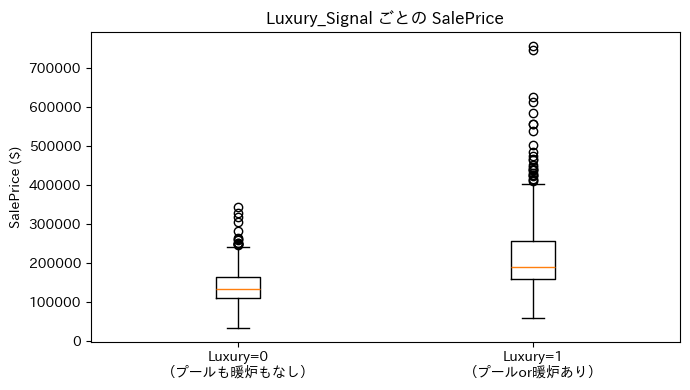

Luxury=0 の中央価格: $135,000
Luxury=1 の中央価格: $191,000


In [ ]:
# ② ドメイン知識を使う（スライド p.116）
# 「プールまたは暖炉がある = 高級住宅シグナル」
train_fe['Luxury_Signal'] = (
    (train_fe['PoolArea'] > 0) | (train_fe['Fireplaces'] > 0)
).astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
group0 = train_fe[train_fe['Luxury_Signal'] == 0]['SalePrice']
group1 = train_fe[train_fe['Luxury_Signal'] == 1]['SalePrice']
ax.boxplot([group0, group1],
           labels=['Luxury=0\n（プールも暖炉もなし）', 'Luxury=1\n（プールor暖炉あり）'])
ax.set_ylabel('SalePrice ($)')
ax.set_title('Luxury_Signal ごとの SalePrice')
plt.tight_layout()
plt.show()

print(f'Luxury=0 の中央価格: ${group0.median():,.0f}')
print(f'Luxury=1 の中央価格: ${group1.median():,.0f}')

### 🟡 QUIZ ─ 穴埋め演習：新しい特徴量を作って相関を確認しよう

「築年数（HouseAge）」は住宅価格と関係が強そうです。  
`YrSold - YearBuilt` で計算し、SalePrice との相関係数と散布図を確認しましょう。


In [ ]:
# 🟡 QUIZ：築年数 HouseAge を作成して効果を確認する
train_fe2 = train.copy()

# ── ❶ 築年数を計算する ──────────────────────────────────────
train_fe2['HouseAge'] = ___ - ___   # 売却年 - 建築年

# ── ❷ SalePrice との相関係数を計算する ─────────────────────────
r = train_fe2['HouseAge'].corr(train_fe2['SalePrice'])
print(f'HouseAge と SalePrice の相関係数: {r:.3f}')

# ── ❸ 散布図を描く ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train_fe2['HouseAge'], np.log1p(train_fe2['SalePrice']),
           alpha=0.4, s=15, color='steelblue')
ax.set_xlabel('HouseAge（築年数）')
ax.set_ylabel('log1p(SalePrice)')
ax.set_title(f'HouseAge vs log1p(SalePrice)  (r = {r:.3f})')
plt.tight_layout()
plt.show()

# ── ❹ 別の組み合わせも作ってみよう ───────────────────────────
# リフォームからの経過年数 = YrSold - YearRemodAdd
train_fe2['RemodAge'] = ___ - ___
r2 = train_fe2['RemodAge'].corr(train_fe2['SalePrice'])
print(f'RemodAge と SalePrice の相関係数: {r2:.3f}')

# ── ❺ 考察 ───────────────────────────────────────────────────
# Q: HouseAge と RemodAge、どちらが SalePrice とより強く相関していますか？
# A: （ここに考えを書いてみよう）

TypeError: unsupported operand type(s) for -: 'str' and 'str'

### 🟢 FREE ─ 自由実装：自分だけの特徴量を作ってみよう

**スライド p.117 の指針**を参考に、オリジナルの特徴量を考えてみましょう。

```
ヒント例：
  TotalBath     = FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath
  LotRatio      = GrLivArea / LotArea   （敷地に対する居住面積の割合）
  QualxArea     = OverallQual * GrLivArea
  HasGarage     = (GarageCars > 0).astype(int)
```


In [ ]:
# 🟢 FREE：オリジナル特徴量を作ってみよう
train_fe3 = train.copy()

# ↓↓↓ ここに自由にコードを書こう ↓↓↓

# 例：バスルーム合計
train_fe3['TotalBath'] = (train_fe3['FullBath']
                         + 0.5 * train_fe3['HalfBath']
                         + train_fe3['BsmtFullBath']
                         + 0.5 * train_fe3['BsmtHalfBath'])

r = train_fe3['TotalBath'].corr(train_fe3['SalePrice'])
print(f'TotalBath と SalePrice の相関: {r:.3f}')

# さらに別の特徴量を追加してみよう！

---
## 6. 特徴量選択（スライド p.118〜123）

特徴量が増えすぎると、**本当に重要な特徴量が埋もれて**しまいます。  
2 つの観点で不要な特徴量を削除しましょう。

1. **多重共線性**：特徴量同士の相関が強い → 一方を削除（スライド p.121）
2. **目的変数との相関が弱い**：ノイズになるリスクがある → 閾値で機械的に削除（スライド p.122）


### 🔵 DEMO ─ 多重共線性のヒートマップ・相関フィルタの可視化


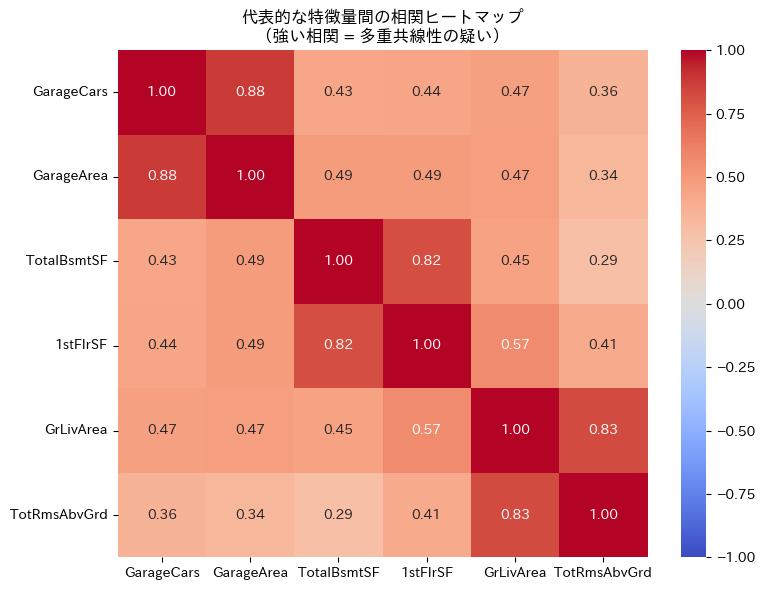

GarageCars と GarageArea の相関係数: 0.882


In [ ]:
# ① 多重共線性の確認（スライド p.121）
cols_garage = ['GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'TotRmsAbvGrd']
corr_matrix = train[cols_garage].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
ax.set_title('代表的な特徴量間の相関ヒートマップ\n（強い相関 = 多重共線性の疑い）')
plt.tight_layout()
plt.show()

print(f'GarageCars と GarageArea の相関係数: {train["GarageCars"].corr(train["GarageArea"]):.3f}')

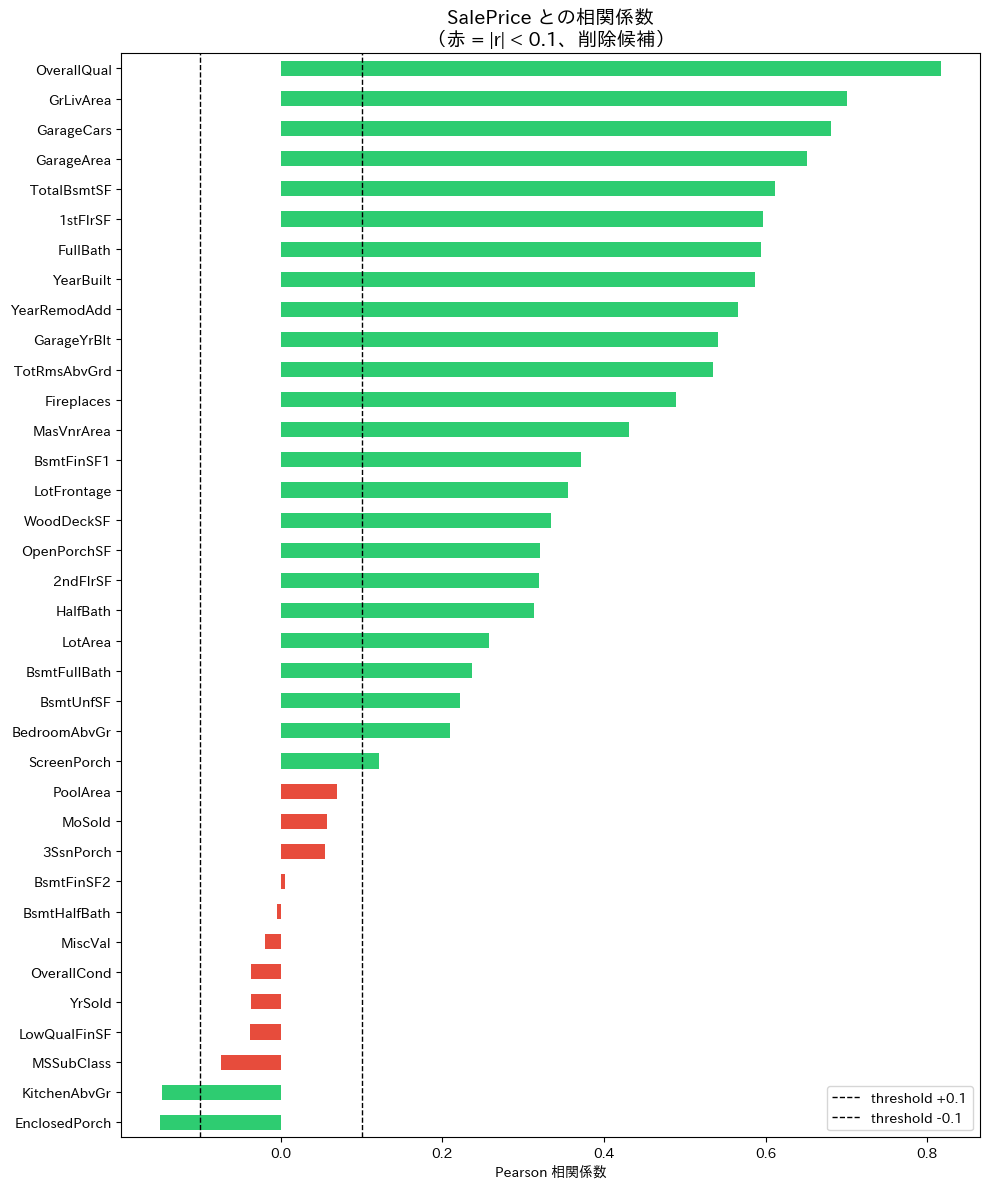

In [ ]:
# ② 目的変数との相関が弱い特徴量を可視化（スライド p.122）
y_log = np.log1p(train['SalePrice'])
X_num = train.select_dtypes(include='number').drop(columns=['SalePrice', 'Id'])
corr_with_target = X_num.corrwith(y_log).sort_values()

colors = ['#e74c3c' if abs(v) < 0.1 else '#2ecc71' for v in corr_with_target]

fig, ax = plt.subplots(figsize=(10, 12))
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x= 0.1, color='black', linestyle='--', linewidth=1, label='threshold +0.1')
ax.axvline(x=-0.1, color='black', linestyle='--', linewidth=1, label='threshold -0.1')
ax.set_title('SalePrice との相関係数\n（赤 = |r| < 0.1、削除候補）', fontsize=14)
ax.set_xlabel('Pearson 相関係数')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 削除候補リストを確認する
THRESHOLD = 0.1
weak_features = corr_with_target[corr_with_target.abs() < THRESHOLD].index.tolist()

print(f'|r| < {THRESHOLD} の特徴量（削除候補）: {len(weak_features)} 個')
print(weak_features)

|r| < 0.1 の特徴量（削除候補）: 10 個
['MSSubClass', 'LowQualFinSF', 'YrSold', 'OverallCond', 'MiscVal', 'BsmtHalfBath', 'BsmtFinSF2', '3SsnPorch', 'MoSold', 'PoolArea']


### 🟡 QUIZ ─ 穴埋め演習：多重共線性ペアを自分で探してみよう

全数値特徴量の相関行列から、**相関係数が 0.8 以上のペア**を抽出してみましょう。


In [ ]:
# 🟡 QUIZ：相関係数 0.8 以上の特徴量ペアを抽出する
X_num = train.select_dtypes(include='number').drop(columns=['SalePrice', 'Id'])

# ── ❶ 相関行列を計算する ─────────────────────────────────────
corr_all = X_num.___()   # .corr() で相関行列を求める

# ── ❷ 上三角行列だけ取り出して高相関ペアを探す ──────────────────
high_corr_pairs = []
cols = corr_all.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r_val = corr_all.iloc[i, j]
        if abs(r_val) >= ___:   # 閾値（0.8）を入れよう
            high_corr_pairs.append((cols[i], cols[j], round(r_val, 3)))

print(f'相関係数 |r| >= 0.8 のペア: {len(high_corr_pairs)} 組')
print()
for col_a, col_b, r_val in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f'  {col_a:<20} ×  {col_b:<20}  r = {r_val}')

# ── ❸ 考察 ───────────────────────────────────────────────────
# Q: 最も相関が強いペアはどれですか？どちらを残しますか？
# A: （ここに考えを書いてみよう）

### 🟢 FREE ─ 自由実装：閾値を変えて削除する列数を調整してみよう


In [ ]:
# 🟢 FREE：THRESHOLD を変えて、削除候補の特徴量数がどう変わるか確認しよう

# ↓↓↓ ここに自由にコードを書こう ↓↓↓

y_log  = np.log1p(train['SalePrice'])
X_num2 = train.select_dtypes(include='number').drop(columns=['SalePrice', 'Id'])
corr2  = X_num2.corrwith(y_log).abs()

for thresh in [0.05, 0.10, 0.15, 0.20]:
    n_drop = (corr2 < thresh).sum()
    print(f'閾値 {thresh:.2f} → 削除候補: {n_drop:2d} 特徴量')

# さらに: 削除したほうがいい特徴量・残したほうがいい特徴量を
# ドメイン知識から考えてみよう

---
## 7. まとめパイプライン＋改善後のモデルを評価しよう

ここまで学んだ手法をすべて組み込んで、**ベースラインとスコアを比較**します。

---

### 🔵 DEMO ─ 全工程をまとめたパイプライン（そのまま使えます）

> このセクションのコードは **実際の改善提出に使えるコード** です。  
> `add_features()` の中身や `THRESHOLD` を変えることで、スコアが変わります。

---

### パイプライン構成

```
(A) 特徴量エンジニアリング  →  (B) 前処理（対数変換・欠損補完・ダミー化）
  →  (C) 特徴量選択（相関フィルタ）  →  (D) モデル学習・評価
```


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# (A) 特徴量エンジニアリング
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def add_features(df):
    df = df.copy()
    # ① 組み合わせ特徴量
    df['TotalSF']        = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
    df['LotArea_x_Qual'] = df['LotArea']  * df['OverallQual']
    df['Age_Plus_Remod'] = df['YearBuilt'] + df['YearRemodAdd']
    # ② ドメイン知識
    df['Luxury_Signal']  = ((df['PoolArea'] > 0) | (df['Fireplaces'] > 0)).astype(int)
    # ③ 築年数
    df['HouseAge']       = df['YrSold'] - df['YearBuilt']
    return df

train_imp = add_features(train)
test_imp  = add_features(test)

print('✅ (A) 特徴量エンジニアリング完了')
print(f'   追加列: {[c for c in train_imp.columns if c not in train.columns]}')


✅ (A) 特徴量エンジニアリング完了
   追加列: ['TotalSF', 'LotArea_x_Qual', 'Age_Plus_Remod', 'Luxury_Signal', 'HouseAge']


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# (B) 前処理
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
y_imp      = np.log1p(train_imp['SalePrice'])
X_imp      = train_imp.drop(columns=['SalePrice', 'Id'])
X_test_imp = test_imp.drop(columns=['Id']).copy()

all_imp = pd.concat([X_imp, X_test_imp], axis=0).reset_index(drop=True)

# 対数変換（歪度 > 0.75 の特徴量）
skew_series = all_imp.select_dtypes(include='number').skew()
skew_cols   = skew_series[skew_series.abs() > 0.75].index
for col in skew_cols:
    all_imp[col] = np.log1p(all_imp[col].clip(lower=0))

# 数値欠損：中央値補完
for col in all_imp.select_dtypes(include='number').columns:
    all_imp[col] = all_imp[col].fillna(all_imp[col].median())

# カテゴリ欠損：NA = 設備なし → 'None', それ以外 → 'Missing'
na_means_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in na_means_none:
    if col in all_imp.columns:
        all_imp[col] = all_imp[col].fillna('None')
for col in all_imp.select_dtypes(include='object').columns:
    all_imp[col] = all_imp[col].fillna('Missing')

all_imp = pd.get_dummies(all_imp, drop_first=True)

print('✅ (B) 前処理完了')
print(f'   特徴量数（前処理後）: {all_imp.shape[1]}')

✅ (B) 前処理完了
   特徴量数（前処理後）: 272


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# (C) 特徴量選択
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
THRESHOLD = 0.1   # ← この値を変えると選択される特徴量数が変わる

X_imp_proc = all_imp.iloc[:len(X_imp)].copy()
y_corr     = X_imp_proc.corrwith(y_imp).abs()
keep_cols  = y_corr[y_corr >= THRESHOLD].index

all_imp_sel     = all_imp[keep_cols]
X_imp_proc      = all_imp_sel.iloc[:len(X_imp)].copy()
X_test_imp_proc = all_imp_sel.iloc[len(X_imp):].copy()

print('✅ (C) 特徴量選択完了')
print(f'   特徴量数: {all_imp.shape[1]} → {len(keep_cols)} 列')

✅ (C) 特徴量選択完了
   特徴量数: 272 → 133 列


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# (D) モデル学習・評価
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_imp_proc, y_imp, test_size=0.2, random_state=42
)

model_improved = LinearRegression()
model_improved.fit(X_tr, y_tr)

rmse_improved = np.sqrt(mean_squared_error(y_vl, model_improved.predict(X_vl)))

print('✅ (D) 学習・評価完了')
print(f'\n🔵 【ベースライン RMSE】 {rmse_baseline:.5f}')
print(f'🟢 【改善後    RMSE】 {rmse_improved:.5f}')
improvement = (rmse_baseline - rmse_improved) / rmse_baseline * 100
print(f'\n   改善率: {improvement:+.2f}%')

✅ (D) 学習・評価完了

🔵 【ベースライン RMSE】 0.17367
🟢 【改善後    RMSE】 0.13192

   改善率: +24.04%


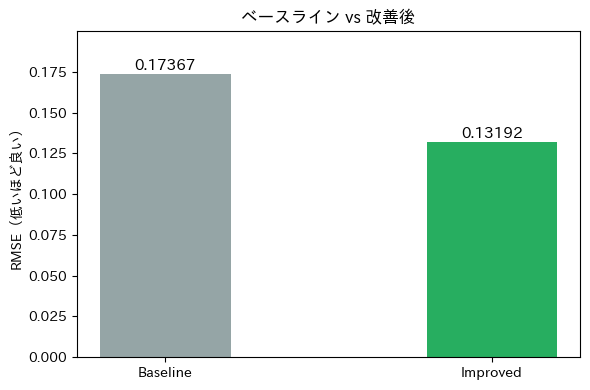

In [ ]:
# ベースラインと改善後のスコアを棒グラフで比較
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Baseline', 'Improved']
values = [rmse_baseline, rmse_improved]
bar_colors = ['#95a5a6', '#27ae60']
bars = ax.bar(labels, values, color=bar_colors, width=0.4)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0005,
            f'{v:.5f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('RMSE（低いほど良い）')
ax.set_title('ベースライン vs 改善後')
ax.set_ylim(0, max(values) * 1.15)
plt.tight_layout()
plt.show()

### 🟢 FREE ─ 自由実装：パイプラインをカスタマイズしてスコアを伸ばそう！

上のパイプライン（A〜D）を改造して、RMSE をさらに下げてみましょう。  
**改善後のスコアを班のメンバーと比べてください（スライド p.126）。**

---

**アイデアのヒント**

| 改良ポイント | やること |
|:---|:---|
| 🏗 特徴量追加 | `add_features()` に新しい列を追加する |
| ✂️ 閾値調整 | `THRESHOLD` を `0.05` / `0.15` / `0.2` に変える |
| 🔗 多重共線性 | `GarageCars` / `GarageArea` の片方を削除してみる |
| 🔢 スケール | 標準化（`StandardScaler`）を前処理に加えてみる |


In [ ]:
# 🟢 FREE：パイプラインをカスタマイズしてみよう
# ── ここに改良した add_features() や THRESHOLD を書いて
#    下のセルをそのまま実行すれば RMSE が更新されます ──

# ↓↓↓ ここに自由にコードを書こう ↓↓↓

def add_features_custom(df):
    df = df.copy()
    # --- ベースの特徴量（変えなくてOK）---
    df['TotalSF']        = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
    df['LotArea_x_Qual'] = df['LotArea']  * df['OverallQual']
    df['Age_Plus_Remod'] = df['YearBuilt'] + df['YearRemodAdd']
    df['Luxury_Signal']  = ((df['PoolArea'] > 0) | (df['Fireplaces'] > 0)).astype(int)
    df['HouseAge']       = df['YrSold'] - df['YearBuilt']
    # --- ↓ここに新しい特徴量を追加しよう ---


    return df

THRESHOLD_CUSTOM = 0.1   # ← 変えてみよう

# ── 以下は変更不要（自動で評価されます）───────────────────────────────────
train_c = add_features_custom(train)
test_c  = add_features_custom(test)

y_c      = np.log1p(train_c['SalePrice'])
X_c      = train_c.drop(columns=['SalePrice', 'Id'])
X_test_c = test_c.drop(columns=['Id']).copy()

all_c = pd.concat([X_c, X_test_c], axis=0).reset_index(drop=True)

skew_c = all_c.select_dtypes(include='number').skew()
for col in skew_c[skew_c.abs() > 0.75].index:
    all_c[col] = np.log1p(all_c[col].clip(lower=0))
for col in all_c.select_dtypes(include='number').columns:
    all_c[col] = all_c[col].fillna(all_c[col].median())
na_cols = ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
           'GarageType','GarageFinish','GarageQual','GarageCond',
           'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType']
for col in na_cols:
    if col in all_c.columns:
        all_c[col] = all_c[col].fillna('None')
for col in all_c.select_dtypes(include='object').columns:
    all_c[col] = all_c[col].fillna('Missing')
all_c = pd.get_dummies(all_c, drop_first=True)

Xc_proc = all_c.iloc[:len(X_c)].copy()
yc_corr = Xc_proc.corrwith(y_c).abs()
keep_c  = yc_corr[yc_corr >= THRESHOLD_CUSTOM].index
Xc_proc      = all_c[keep_c].iloc[:len(X_c)].copy()
Xc_test_proc = all_c[keep_c].iloc[len(X_c):].copy()

Xc_tr, Xc_vl, yc_tr, yc_vl = train_test_split(Xc_proc, y_c, test_size=0.2, random_state=42)
model_custom = LinearRegression()
model_custom.fit(Xc_tr, yc_tr)
rmse_custom = np.sqrt(mean_squared_error(yc_vl, model_custom.predict(Xc_vl)))

print(f'🔵 【ベースライン RMSE】 {rmse_baseline:.5f}')
print(f'🟢 【改善後    RMSE】 {rmse_improved:.5f}')
print(f'🌟 【自分の    RMSE】 {rmse_custom:.5f}')
gain = (rmse_baseline - rmse_custom) / rmse_baseline * 100
print(f'\n   ベースラインからの改善率: {gain:+.2f}%')


🔵 【ベースライン RMSE】 0.17367
🟢 【改善後    RMSE】 0.13192
🌟 【自分の    RMSE】 0.13192

   ベースラインからの改善率: +24.04%


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


---
## 8. 提出ファイルを作成しよう


> 🔵 **DEMO** ─ セクション 7 の `model_custom` と `Xc_test_proc` を使って提出ファイルを生成します。  
> セクション 7 の FREE セルを実行してから、このセルを実行してください。


In [ ]:
test_pred_log = model_custom.predict(Xc_test_proc)
test_pred     = np.expm1(test_pred_log)   # log1p の逆変換

submission = pd.DataFrame({
    'Id'       : test_ids,
    'SalePrice': test_pred
})

submission.to_csv('submission_improved.csv', index=False)
print('✅ 提出用ファイル submission_improved.csv を作成しました！')
print(submission.head())

✅ 提出用ファイル submission_improved.csv を作成しました！
     Id      SalePrice
0  1461  105847.272608
1  1462  156797.429017
2  1463  181218.202350
3  1464  186130.583690
4  1465  224972.024896


---
## 📝 まとめ

| ステップ | 学んだこと |
|:---|:---|
| **EDA** | 基本統計量・分布の可視化・散布図・欠損値の2種類 |
| **前処理** | スケール問題・対数変換・標準化 |
| **特徴量作成** | 特徴量の組み合わせ・ドメイン知識の活用 |
| **特徴量選択** | 多重共線性の排除・相関フィルタ |

